# Probability-orthonormal basis approximations by activation

The figures compare ReLU, tanh, and RePU-2 emulators for both supported
families:

$$
\psi_n^L(x)=\sqrt{2n+1}P_n(x),\qquad d\rho_L(x)=\frac{dx}{2},
$$

and

$$
\psi_0^C(x)=1,\qquad \psi_n^C(x)=\sqrt2T_n(x)\ (n\geq1),
\qquad d\rho_C(x)=\frac{dx}{\pi\sqrt{1-x^2}}.
$$


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch

from neural_polynomial_emulation import (
    emulated_chebyshev_basis,
    emulated_legendre_basis,
    exact_chebyshev_basis,
    exact_legendre_basis,
)

PMAX = 20
FAMILIES = ("legendre", "chebyshev")
NUM_POINTS = 1201
RELU_LAYERS = 16
TANH_TOLERANCE = 1e-4

if PMAX < 0:
    raise ValueError("PMAX must be nonnegative")

FAMILY_APIS = {
    "legendre": {
        "label": "Legendre",
        "exact": exact_legendre_basis,
        "emulated": emulated_legendre_basis,
    },
    "chebyshev": {
        "label": "Chebyshev",
        "exact": exact_chebyshev_basis,
        "emulated": emulated_chebyshev_basis,
    },
}
unknown_families = set(FAMILIES) - set(FAMILY_APIS)
if unknown_families:
    raise ValueError(f"unknown families: {sorted(unknown_families)}")


## Basis evaluation

Each emulator returns every basis column from degree zero through `PMAX`.
The tanh construction uses automatic tolerance- and dtype-dependent step
selection.


In [2]:
x = torch.linspace(-1.0, 1.0, NUM_POINTS, dtype=torch.float64)
x_numpy = x.numpy()
basis_data = {}

for family in FAMILIES:
    api = FAMILY_APIS[family]
    exact = api["exact"](x, PMAX).numpy()
    approximations = {
        "ReLU": api["emulated"](
            x, PMAX, product="relu", num_layers=RELU_LAYERS
        ).numpy(),
        "tanh": api["emulated"](
            x, PMAX, product="tanh", tanh_tolerance=TANH_TOLERANCE
        ).numpy(),
        "RePU-2": api["emulated"](x, PMAX, product="repu2").numpy(),
    }
    basis_data[family] = {"exact": exact, "approximations": approximations}


## Approximations

Rows index degree and columns index multiplication activation. Each panel
reports the grid maximum error. The family heading is kept in a separate
figure margin so it does not overlap the column titles or the plots.


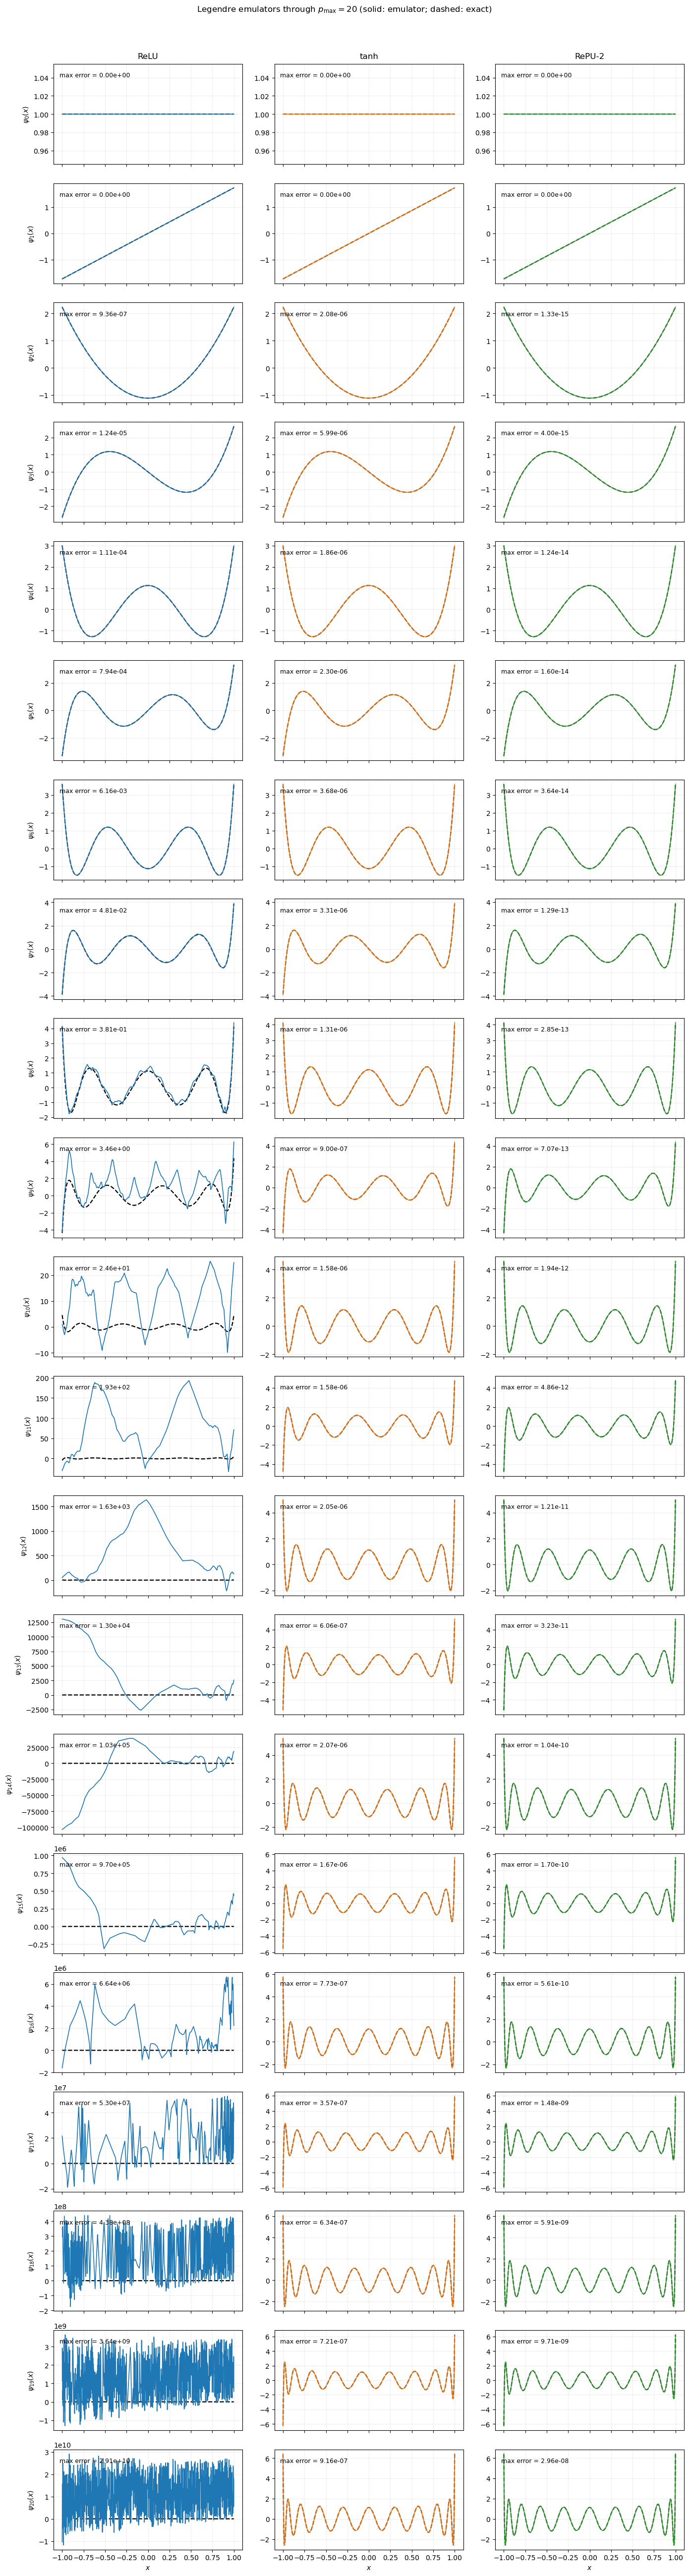

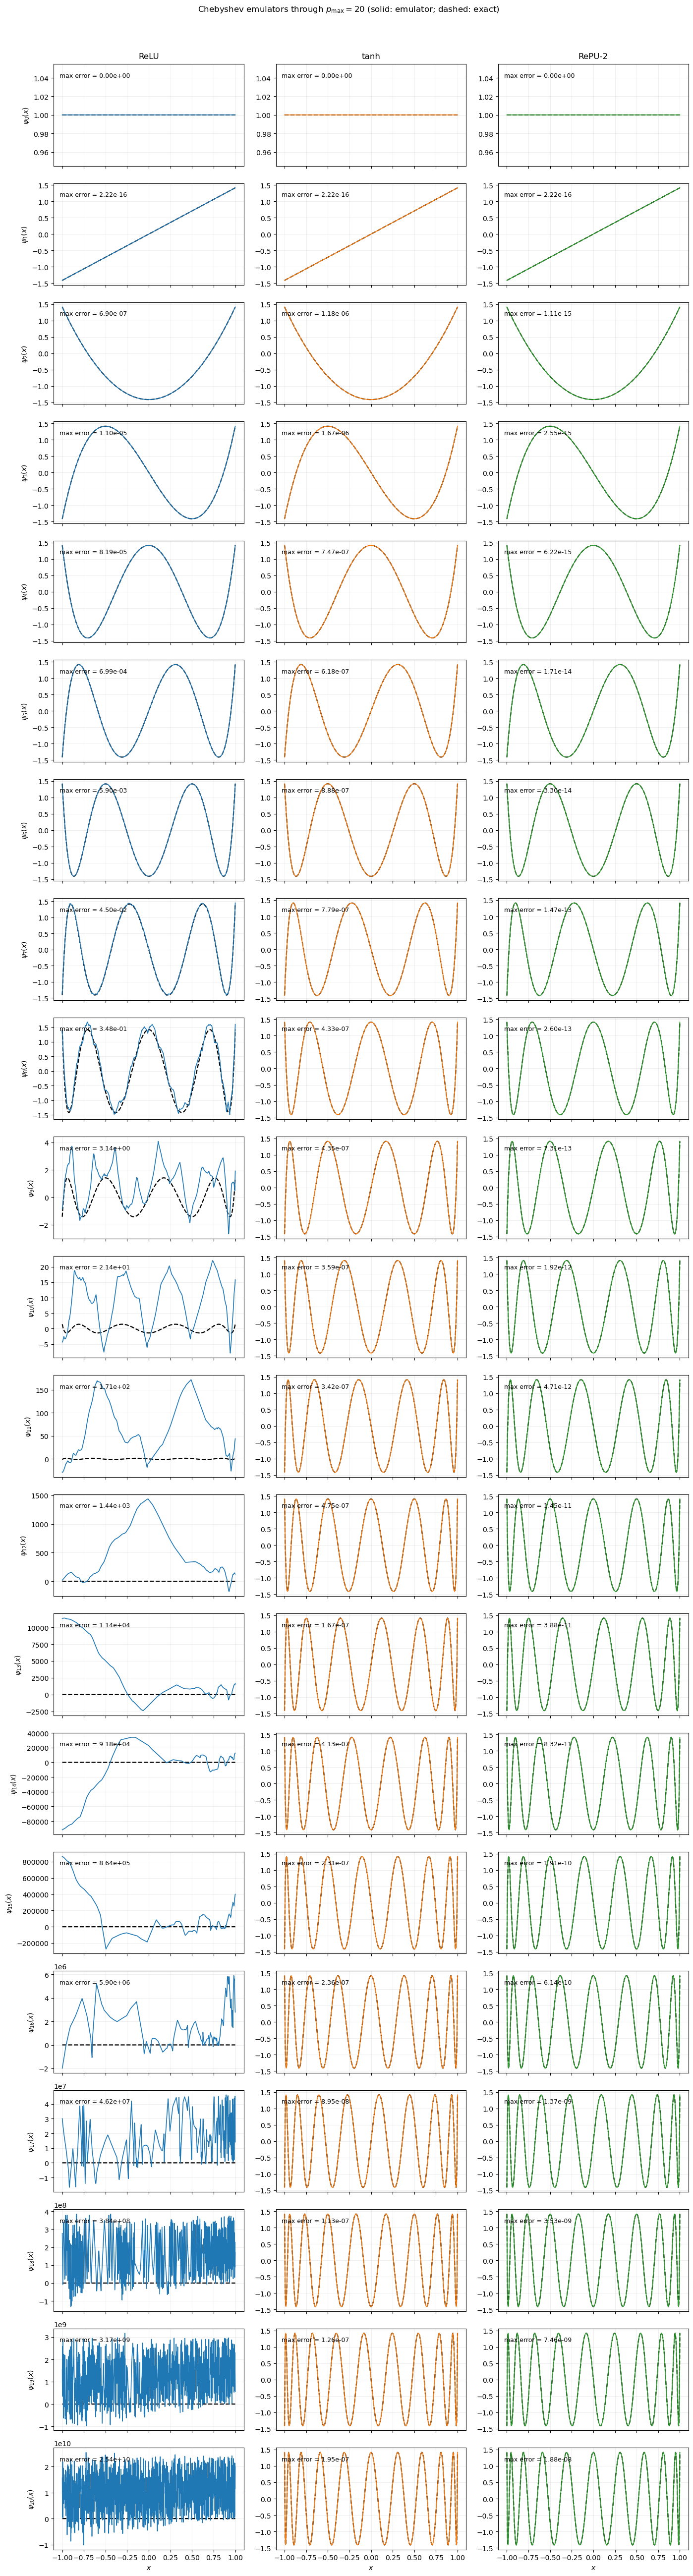

In [3]:
colors = {"ReLU": "tab:blue", "tanh": "tab:orange", "RePU-2": "tab:green"}
row_height = 2.45
header_height = 0.52

for family in FAMILIES:
    exact = basis_data[family]["exact"]
    approximations = basis_data[family]["approximations"]
    figure_height = row_height * (PMAX + 1) + header_height
    fig, axes = plt.subplots(
        PMAX + 1,
        len(approximations),
        figsize=(14, figure_height),
        sharex=True,
        squeeze=False,
    )

    for degree in range(PMAX + 1):
        for column, (name, approximate) in enumerate(approximations.items()):
            ax = axes[degree, column]
            ax.plot(
                x_numpy,
                exact[:, degree],
                color="black",
                linestyle="--",
                linewidth=1.6,
            )
            ax.plot(
                x_numpy,
                approximate[:, degree],
                color=colors[name],
                linewidth=1.2,
            )
            error = np.max(np.abs(approximate[:, degree] - exact[:, degree]))
            ax.text(
                0.03,
                0.92,
                f"max error = {error:.2e}",
                transform=ax.transAxes,
                va="top",
                fontsize=9,
            )
            ax.grid(alpha=0.2)
            if degree == 0:
                ax.set_title(name, pad=8)
            if column == 0:
                ax.set_ylabel(rf"$\psi_{{{degree}}}(x)$")
            if degree == PMAX:
                ax.set_xlabel(r"$x$")

    fig.suptitle(
        rf"{FAMILY_APIS[family]['label']} emulators through "
        rf"$p_{{\max}}={PMAX}$ (solid: emulator; dashed: exact)",
        y=1.0 - 0.04 / figure_height,
        va="top",
    )
    fig.tight_layout(rect=(0, 0, 1, 1.0 - header_height / figure_height))
    plt.show()
